# DeflectionNet
## Direct neural emulator for the Schwarzschild deflection angle

This notebook trains a dedicated neural network to emulate the **deflection angle**
$$
\delta\phi = \Delta\phi - \pi
$$
for Schwarzschild photon scattering trajectories.

## Motivation
OrbitNet emulates the full orbital solution $u(\phi)$, but the deflection angle is a **global observable**.  
A dedicated network for $\delta\phi$ can be:

- simpler,
- faster,
- easier to benchmark,
- and directly useful when the user only needs the lensing observable.

## Strategy
We train a regression model only on **valid scattering cases**, i.e. when
$$
b > b_{\rm crit} = \frac{3\sqrt{3}}{2}R_S.
$$

The benchmark compares the neural prediction against:
1. the exact analytic expression from the paper (Eq. 56),
2. the weak-field approximation (Eq. 65),
3. the strong-field approximation (Eq. 66).

In [1]:
import os
import json
import math
import time
import random
import itertools
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from scipy.special import ellipk, ellipkinc
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

USE_DRACULA = True
if USE_DRACULA:
    import matplotx
    plt.style.use(matplotx.styles.dracula)

plt.rcParams.update({
    "figure.titlesize": 20,
    "axes.titlesize": 14,
    "axes.labelsize": 14,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "legend.fontsize": 11,
    "lines.linewidth": 2.4,
})

BASE = "/home/kingsman/Escritorio/PhD/PINN_paper/best_orbinet"
OUT_BASE = os.path.join(BASE, "deflection_net")
OUT_DATA = os.path.join(OUT_BASE, "data")
OUT_CKPT = os.path.join(OUT_BASE, "ckpt")
OUT_TAB  = os.path.join(OUT_BASE, "tables")
OUT_FIGS = os.path.join(OUT_BASE, "figs")

for d in [OUT_BASE, OUT_DATA, OUT_CKPT, OUT_TAB, OUT_FIGS]:
    os.makedirs(d, exist_ok=True)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("DEVICE:", DEVICE)
print("OUT_BASE:", OUT_BASE)

DEVICE: cuda
OUT_BASE: /home/kingsman/Escritorio/PhD/PINN_paper/best_orbinet/deflection_net


## Exact analytic deflection angle

We implement the exact expression derived in the paper for the Schwarzschild deflection angle.

For scattering trajectories:
$$
\delta\phi = \Delta\phi - \pi,
$$
with $\Delta\phi$ given by Eq. (56).

We also implement:
- the critical impact parameter,
- the weak-field approximation,
- the strong-field approximation.

In [2]:
def bcrit(Rs):
    return 1.5 * np.sqrt(3.0) * Rs

def cubic_roots_u(Rs, b):
    # u^3 - u^2 + (Rs/b)^2 = 0
    coeff = [1.0, -1.0, 0.0, (Rs/b)**2]
    roots = np.roots(coeff)
    roots = np.real_if_close(roots, tol=1e5)
    if np.any(np.abs(np.imag(roots)) > 1e-10):
        return None
    roots = np.sort(np.real(roots))
    return roots

def deflection_exact_eq56(Rs, b):
    roots = cubic_roots_u(Rs, b)
    if roots is None:
        return np.nan, {}

    u1, u2, u3 = roots

    # valid scattering branch
    if not (u1 < 0 < u2 < u3 < 1):
        return np.nan, {"u1": u1, "u2": u2, "u3": u3}

    m = (u2 - u1) / (u3 - u1)   # m = k^2
    if not (0 <= m < 1):
        return np.nan, {"u1": u1, "u2": u2, "u3": u3, "m": m}

    z = np.sqrt((-u1) / (u2 - u1))
    z = np.clip(z, 0.0, 1.0)

    K_complete = ellipk(m)
    F_incomplete = ellipkinc(np.arcsin(z), m)

    Delta_phi = 4.0 / np.sqrt(u3 - u1) * (K_complete - F_incomplete)
    delta_phi = Delta_phi - np.pi

    aux = {
        "u1": u1, "u2": u2, "u3": u3,
        "m": m, "z": z,
        "Delta_phi": Delta_phi
    }
    return float(delta_phi), aux

def deflection_weak_eq65(Rs, b):
    x = Rs / b
    return float(2*x + (15*np.pi/16)*(x**2) + (16/3)*(x**3))

def deflection_strong_eq66(Rs, b):
    denom = 1.0 - (3*np.sqrt(3)*Rs/(2*b))**2
    if denom <= 0:
        return np.nan
    Delta_phi = np.log(432*(2-np.sqrt(3))**2 / denom)
    return float(Delta_phi - np.pi)

## Sanity check of the exact formula

In [3]:
Rs_test = 1.0
bc_test = bcrit(Rs_test)
b_vals = np.linspace(1.01*bc_test, 1.20*bc_test, 6)

rows = []
for b in b_vals:
    rows.append({
        "b": b,
        "b/bc": b / bc_test,
        "delta_exact": deflection_exact_eq56(Rs_test, b)[0],
        "delta_weak": deflection_weak_eq65(Rs_test, b),
        "delta_strong": deflection_strong_eq66(Rs_test, b),
    })

pd.DataFrame(rows)

,b,b/bc,delta_exact,delta_weak,delta_strong
0,2.624057,1.010,4.229662,1.485088,4.219853
1,2.722784,1.048,2.732895,1.396037,2.706375
2,2.821511,1.086,2.210576,1.316242,2.176079
3,2.920238,1.124,1.899473,1.244409,1.860877
4,3.018965,1.162,1.682711,1.179461,1.642328
5,3.117691,1.200,1.519186,1.120503,1.478541


## Build the regression dataset

We generate a synthetic dataset of valid scattering cases only.

### Inputs
We use a compact set of global features:
- $R_S$,
- $b$,
- $b/b_c$,
- $R_S/b$,
- $\log(b/b_c - 1)$.

These features help in both:
- weak/large-$b$ behavior,
- near-critical behavior.

### Target
We predict:
$$
y = \log(1+\delta\phi)
$$
instead of $\delta\phi$ directly, to stabilize the regression.

In [4]:
def make_deflection_dataset(
    n_samples=60000,
    Rs_range=(0.5, 3.0),
    b_ratio_range=(1.01, 2.5),
    seed=123
):
    rng = np.random.default_rng(seed)
    rows = []

    for _ in range(n_samples):
        Rs = rng.uniform(*Rs_range)
        bc = bcrit(Rs)

        # sample in ratio space
        b_ratio = rng.uniform(*b_ratio_range)
        b = b_ratio * bc

        dphi, aux = deflection_exact_eq56(Rs, b)
        if not np.isfinite(dphi):
            continue

        rows.append({
            "Rs": Rs,
            "b": b,
            "bc": bc,
            "b_over_bc": b / bc,
            "Rs_over_b": Rs / b,
            "log_gap": np.log((b / bc) - 1.0),
            "delta_phi": dphi,
            "target_log1p": np.log1p(dphi),
        })

    return pd.DataFrame(rows)

df_all = make_deflection_dataset(
    n_samples=60000,
    Rs_range=(0.5, 3.0),
    b_ratio_range=(1.01, 2.5),
    seed=123
)

print(df_all.shape)
display(df_all.head())

csv_data = os.path.join(OUT_DATA, "deflection_dataset.csv")
df_all.to_csv(csv_data, index=False)
print("Saved:", csv_data)

(60000, 8)


,Rs,b,bc,b_over_bc,Rs_over_b,log_gap,delta_phi,target_log1p
0,2.205880,6.247945,5.731043,1.090193,0.353057,-2.405800,2.169271,1.153502
1,1.050900,3.507677,2.730317,1.284714,0.299600,-1.256270,1.261847,0.816182
2,0.939765,5.420359,2.441580,2.220021,0.173377,0.198868,0.478386,0.390951
3,2.808362,10.376095,7.296340,1.422096,0.270657,-0.862523,1.003233,0.694763
4,2.549386,15.472100,6.623500,2.335940,0.164773,0.289635,0.445489,0.368448


Saved: /home/kingsman/Escritorio/PhD/PINN_paper/best_orbinet/deflection_net/data/deflection_dataset.csv


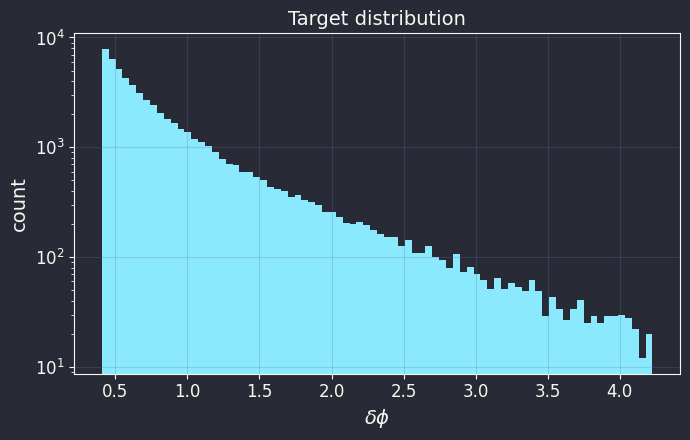

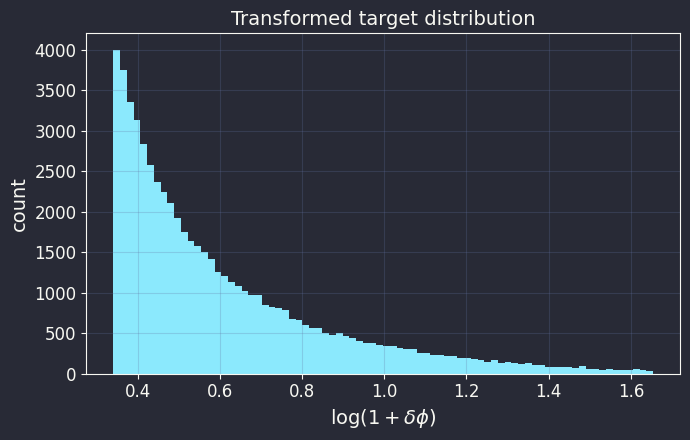

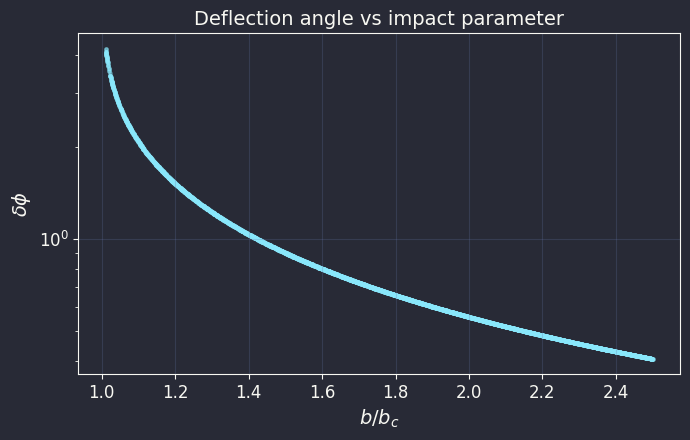

In [5]:
fig, ax = plt.subplots(figsize=(7,4.5))
ax.hist(df_all["delta_phi"], bins=80)
ax.set_yscale("log")
ax.set_xlabel(r"$\delta\phi$")
ax.set_ylabel("count")
ax.set_title("Target distribution")
ax.grid(True, alpha=0.25)
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(7,4.5))
ax.hist(df_all["target_log1p"], bins=80)
ax.set_xlabel(r"$\log(1+\delta\phi)$")
ax.set_ylabel("count")
ax.set_title("Transformed target distribution")
ax.grid(True, alpha=0.25)
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(7,4.5))
ax.scatter(df_all["b_over_bc"].sample(5000, random_state=0),
           df_all["delta_phi"].sample(5000, random_state=0),
           s=6, alpha=0.35)
ax.set_yscale("log")
ax.set_xlabel(r"$b/b_c$")
ax.set_ylabel(r"$\delta\phi$")
ax.set_title("Deflection angle vs impact parameter")
ax.grid(True, alpha=0.25)
plt.tight_layout()
plt.show()

In [6]:
#train and validation split
FEATURES = ["Rs", "b", "b_over_bc", "Rs_over_b", "log_gap"]
TARGET = "target_log1p"

train_df, temp_df = train_test_split(df_all, test_size=0.30, random_state=42)
val_df, test_df = train_test_split(temp_df, test_size=0.50, random_state=42)

print("train:", train_df.shape)
print("val  :", val_df.shape)
print("test :", test_df.shape)

mu_x = train_df[FEATURES].mean().values.astype(np.float32)
std_x = train_df[FEATURES].std().replace(0, 1.0).values.astype(np.float32)

mu_y = train_df[TARGET].mean().astype(np.float32)
std_y = train_df[TARGET].std().astype(np.float32)
if std_y == 0:
    std_y = np.float32(1.0)

norm_info = {
    "features": FEATURES,
    "mu_x": mu_x.tolist(),
    "std_x": std_x.tolist(),
    "target": TARGET,
    "mu_y": float(mu_y),
    "std_y": float(std_y),
}

with open(os.path.join(OUT_TAB, "normalization.json"), "w") as f:
    json.dump(norm_info, f, indent=2)

print("Saved normalization.json")

train: (42000, 8)
val  : (9000, 8)
test : (9000, 8)
Saved normalization.json


In [7]:
#pytorch dataset

class DeflectionDataset(Dataset):
    def __init__(self, df, features, target, mu_x, std_x, mu_y, std_y):
        X = df[features].values.astype(np.float32)
        y = df[target].values.astype(np.float32).reshape(-1, 1)

        self.X = (X - mu_x) / std_x
        self.y = (y - mu_y) / std_y

        self.X = torch.from_numpy(self.X)
        self.y = torch.from_numpy(self.y)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

class MLPDeflectionNet(nn.Module):
    def __init__(self, in_dim, width=128, depth=3, dropout=0.0):
        super().__init__()
        layers = []
        d = in_dim
        for _ in range(depth):
            layers += [
                nn.Linear(d, width),
                nn.GELU(),
                nn.Dropout(dropout),
            ]
            d = width
        layers += [nn.Linear(d, 1)]
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)

In [8]:
#uitilities
def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

def inverse_target(z_norm, mu_y, std_y):
    z = z_norm * std_y + mu_y
    return np.expm1(z)

def evaluate_model(model, loader, mu_y, std_y, device="cpu"):
    model.eval()
    preds = []
    trues = []

    with torch.no_grad():
        for xb, yb in loader:
            xb = xb.to(device)
            yhat = model(xb).cpu().numpy()
            ytrue = yb.cpu().numpy()

            preds.append(yhat)
            trues.append(ytrue)

    preds = np.vstack(preds).squeeze()
    trues = np.vstack(trues).squeeze()

    preds_phys = inverse_target(preds, mu_y, std_y)
    trues_phys = inverse_target(trues, mu_y, std_y)

    mse = mean_squared_error(trues_phys, preds_phys)
    mae = mean_absolute_error(trues_phys, preds_phys)
    r2  = r2_score(trues_phys, preds_phys)

    return {
        "mse": float(mse),
        "mae": float(mae),
        "r2": float(r2),
        "preds_phys": preds_phys,
        "trues_phys": trues_phys,
    }

def train_one_run(
    config,
    train_df, val_df, test_df,
    features, target,
    mu_x, std_x, mu_y, std_y,
    out_ckpt_dir,
    device="cpu"
):
    seed = int(config["seed"])
    set_seed(seed)

    train_ds = DeflectionDataset(train_df, features, target, mu_x, std_x, mu_y, std_y)
    val_ds   = DeflectionDataset(val_df,   features, target, mu_x, std_x, mu_y, std_y)
    test_ds  = DeflectionDataset(test_df,  features, target, mu_x, std_x, mu_y, std_y)

    train_loader = DataLoader(train_ds, batch_size=config["batch"], shuffle=True)
    val_loader   = DataLoader(val_ds, batch_size=1024, shuffle=False)
    test_loader  = DataLoader(test_ds, batch_size=1024, shuffle=False)

    model = MLPDeflectionNet(
        in_dim=len(features),
        width=config["width"],
        depth=config["depth"],
        dropout=config["dropout"],
    ).to(device)

    if config["loss"] == "mse":
        criterion = nn.MSELoss()
    else:
        criterion = nn.SmoothL1Loss(beta=0.1)

    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=config["lr"],
        weight_decay=config["weight_decay"]
    )

    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode="min", factor=0.5, patience=12
    )

    best_val = np.inf
    best_state = None
    train_hist = []
    val_hist = []
    lr_hist = []

    t0 = time.perf_counter()

    for epoch in range(config["epochs"]):
        model.train()
        running = 0.0
        n = 0

        for xb, yb in train_loader:
            xb = xb.to(device)
            yb = yb.to(device)

            optimizer.zero_grad()
            yhat = model(xb)
            loss = criterion(yhat, yb)
            loss.backward()
            optimizer.step()

            running += loss.item() * len(xb)
            n += len(xb)

        train_loss = running / max(n, 1)

        model.eval()
        running = 0.0
        n = 0
        with torch.no_grad():
            for xb, yb in val_loader:
                xb = xb.to(device)
                yb = yb.to(device)
                yhat = model(xb)
                loss = criterion(yhat, yb)
                running += loss.item() * len(xb)
                n += len(xb)

        val_loss = running / max(n, 1)
        scheduler.step(val_loss)

        train_hist.append(train_loss)
        val_hist.append(val_loss)
        lr_hist.append(optimizer.param_groups[0]["lr"])

        if val_loss < best_val:
            best_val = val_loss
            best_state = {
                "model_state": model.state_dict(),
                "config": config,
                "best_val_loss": best_val,
                "epoch": epoch,
                "train_hist": train_hist.copy(),
                "val_hist": val_hist.copy(),
                "lr_hist": lr_hist.copy(),
                "mu_x": mu_x,
                "std_x": std_x,
                "mu_y": mu_y,
                "std_y": std_y,
                "features": features,
                "target": target,
            }

    elapsed = time.perf_counter() - t0

    ckpt_name = f"defl_{config['exp_id']}.pt"
    ckpt_path = os.path.join(out_ckpt_dir, ckpt_name)
    torch.save(best_state, ckpt_path)

    model.load_state_dict(best_state["model_state"])

    val_metrics = evaluate_model(model, val_loader, mu_y, std_y, device=device)
    test_metrics = evaluate_model(model, test_loader, mu_y, std_y, device=device)

    row = dict(config)
    row.update({
        "best_val_loss": float(best_state["best_val_loss"]),
        "best_epoch": int(best_state["epoch"]),
        "val_mse": val_metrics["mse"],
        "val_mae": val_metrics["mae"],
        "val_r2": val_metrics["r2"],
        "test_mse": test_metrics["mse"],
        "test_mae": test_metrics["mae"],
        "test_r2": test_metrics["r2"],
        "elapsed_sec": elapsed,
        "ckpt_path": ckpt_path,
    })
    return row


## Exhaustive hyperparameter sweep

We run a relatively broad sweep over:
- width,
- depth,
- dropout,
- learning rate,
- weight decay,
- batch size,
- loss type,
- random seed.

In [9]:
sweep = {
    "width": [64, 128, 256, 320],
    "depth": [2, 3, 4, 5],
    "dropout": [0.0, 0.05, 0.10],
    "lr": [1e-3, 5e-4, 2e-4],
    "weight_decay": [0.0, 1e-5, 1e-4],
    "batch": [128, 256],
    "loss": ["mse", "huber"],
    "epochs": [140],
    "seed": [11, 22],
}

keys = list(sweep.keys())
values = list(sweep.values())
grid = list(itertools.product(*values))

print("Total runs:", len(grid))

Total runs: 3456


In [10]:
results = []

for i, vals in enumerate(grid):
    cfg = dict(zip(keys, vals))
    cfg["exp_id"] = f"{i:04d}"

    print(f"[{i+1}/{len(grid)}] {cfg}")

    row = train_one_run(
        config=cfg,
        train_df=train_df,
        val_df=val_df,
        test_df=test_df,
        features=FEATURES,
        target=TARGET,
        mu_x=mu_x,
        std_x=std_x,
        mu_y=mu_y,
        std_y=std_y,
        out_ckpt_dir=OUT_CKPT,
        device=DEVICE,
    )
    results.append(row)

    tmp_df = pd.DataFrame(results).sort_values("test_mse")
    tmp_df.to_csv(os.path.join(OUT_TAB, "sweep_results_partial.csv"), index=False)

results_df = pd.DataFrame(results).sort_values("test_mse").reset_index(drop=True)
results_csv = os.path.join(OUT_TAB, "sweep_results.csv")
results_df.to_csv(results_csv, index=False)

print("Saved:", results_csv)
display(results_df.head(15))

[1/3456] {'width': 64, 'depth': 2, 'dropout': 0.0, 'lr': 0.001, 'weight_decay': 0.0, 'batch': 128, 'loss': 'mse', 'epochs': 140, 'seed': 11, 'exp_id': '0000'}
[2/3456] {'width': 64, 'depth': 2, 'dropout': 0.0, 'lr': 0.001, 'weight_decay': 0.0, 'batch': 128, 'loss': 'mse', 'epochs': 140, 'seed': 22, 'exp_id': '0001'}
[3/3456] {'width': 64, 'depth': 2, 'dropout': 0.0, 'lr': 0.001, 'weight_decay': 0.0, 'batch': 128, 'loss': 'huber', 'epochs': 140, 'seed': 11, 'exp_id': '0002'}
[4/3456] {'width': 64, 'depth': 2, 'dropout': 0.0, 'lr': 0.001, 'weight_decay': 0.0, 'batch': 128, 'loss': 'huber', 'epochs': 140, 'seed': 22, 'exp_id': '0003'}
[5/3456] {'width': 64, 'depth': 2, 'dropout': 0.0, 'lr': 0.001, 'weight_decay': 0.0, 'batch': 256, 'loss': 'mse', 'epochs': 140, 'seed': 11, 'exp_id': '0004'}
[6/3456] {'width': 64, 'depth': 2, 'dropout': 0.0, 'lr': 0.001, 'weight_decay': 0.0, 'batch': 256, 'loss': 'mse', 'epochs': 140, 'seed': 22, 'exp_id': '0005'}
[7/3456] {'width': 64, 'depth': 2, 'dropou

KeyboardInterrupt: 

In [ ]:
## Best model
best = results_df.iloc[0].copy()
best